In [1]:
import os
import pandas as pd
import re
import numpy as np
import GEO_to_XYcenter as xysar
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
sargeo_modif_df = pd.read_csv("excels/SARGEO_modifiee.csv")   #chemin vers le csv du sargeo modifiée (liée avec le listing du sar)
sargeo_df = pd.read_csv("excels/SARGEO_cyclones.csv")                   #chemin vers le csv du sargeo
sar_list_df = pd.read_csv("excels/listing_sar.csv")           #chemin vers le csv du listing sar
sargeo_modif_df.fillna(0, inplace=True)
sargeo_modif_df.head(1)

,cyclone,canal,fichier,lat_centre,lon_centre,sar_acquisition_time,inter_list_sar,sar_file_path
0,al102019,IRWIN,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,19.548832,298.289185,"2019-09-20T22:19:52,000",s1a-iw-owi-cm-20190920t221952-20190920t222132-...,0


In [3]:
sargeo_modif_df[sargeo_modif_df[sargeo_modif_df.columns[-1]]==0].head(2)

,cyclone,canal,fichier,lat_centre,lon_centre,sar_acquisition_time,inter_list_sar,sar_file_path
0,al102019,IRWIN,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,19.548832,298.289185,"2019-09-20T22:19:52,000",s1a-iw-owi-cm-20190920t221952-20190920t222132-...,0
2,ep192022,IRWIN,s1a-iw-owi-cm-20221022t130700-20221022t130753-...,17.509211,253.851669,"2022-10-22T13:07:00,000",s1a-iw-owi-cm-20221022t130700-20221022t130753-...,0


In [5]:
sar_folder = "/scale/user/mtannaou/alternance/donnees_sar"      #chemin vers le dossier content les fichiers netcdf des SAR
output_dir = "/scale/user/mtannaou/alternance/donnees_sar_changes"         #chemin d output


df_copy_sar_files = sargeo_modif_df[sargeo_modif_df[sargeo_modif_df.columns[-1]]!=0].copy()
for file_path in df_copy_sar_files[df_copy_sar_files.columns[-1]]:
    try:
        xysar.convert_sar_to_xy(file_path, sargeo_modif_df, output_dir)
    except Exception as e:
        print(f"❌ Erreur pour {file}: {e}")

/scale/user/mtannaou/alternance/GEO_to_XYcenter.py:39: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  x, y = pyproj.transform(
/scale/user/mtannaou/alternance/GEO_to_XYcenter.py:39: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  x, y = pyproj.transform(
/scale/user/mtannaou/alternance/GEO_to_XYcenter.py:39: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  x, y = pyproj.transform(
/scale/user/mtannaou/alternance/GEO_to_XYcenter.py:39: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  x, y = pyproj.transform(
/scale/user/mtannaou/alternance/GEO_to_XYcenter.py:39: FutureWarning: This function is deprecated. See: https://pyproj4.

KeyboardInterrupt: 

In [33]:
ds_irwin = xr.open_dataset("/content/drive/MyDrive/excels/irwin_files/rcm1-sclnd-owi-cm-20240620t004603-20240620t004719-00003-______ll_gd_GEO-IRWIN.nc")
ds_sar_xy = xr.open_dataset("/content/drive/MyDrive/excels/sar_xy/rcm1-sclnd-owi-cm-20240620t004603-20240620t004719-00003-xxxxx_aeqd.nc")


/tmp/ipython-input-3908309485.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time_diff' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_irwin = xr.open_dataset("/content/drive/MyDrive/excels/irwin_files/rcm1-sclnd-owi-cm-20240620t004603-20240620t004719-00003-______ll_gd_GEO-IRWIN.nc")


In [34]:
print(ds_irwin["x"])

<xarray.DataArray 'x' (x: 1001)> Size: 4kB
array([-1000.,  -998.,  -996., ...,   996.,   998.,  1000.], dtype=float32)
Coordinates:
  * x        (x) float32 4kB -1e+03 -998.0 -996.0 -994.0 ... 996.0 998.0 1e+03
Attributes:
    long_name:              The zonal/east-west distance of the center of the...
    standard_name:          projection_x_coordinate
    units:                  km
    valid_range:            [-1000.  1000.]
    comment:                Calculated using the Azimuthal Equidistant projec...
    coverage_content_type:  coordinate


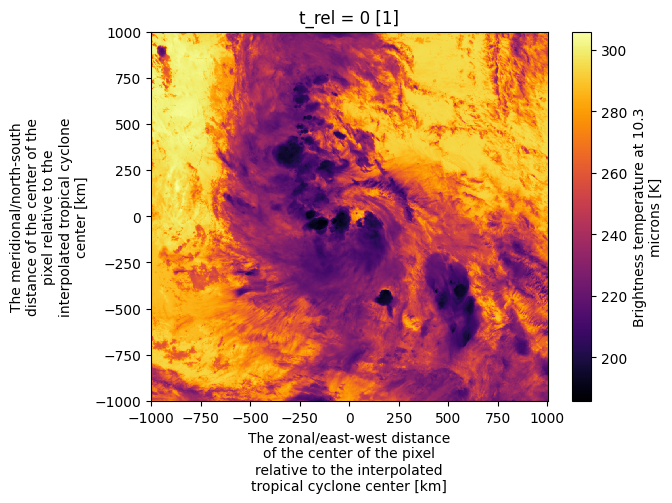

In [35]:
ds_irwin["IRWIN"].sel(t_rel=0).plot.imshow(cmap='inferno')

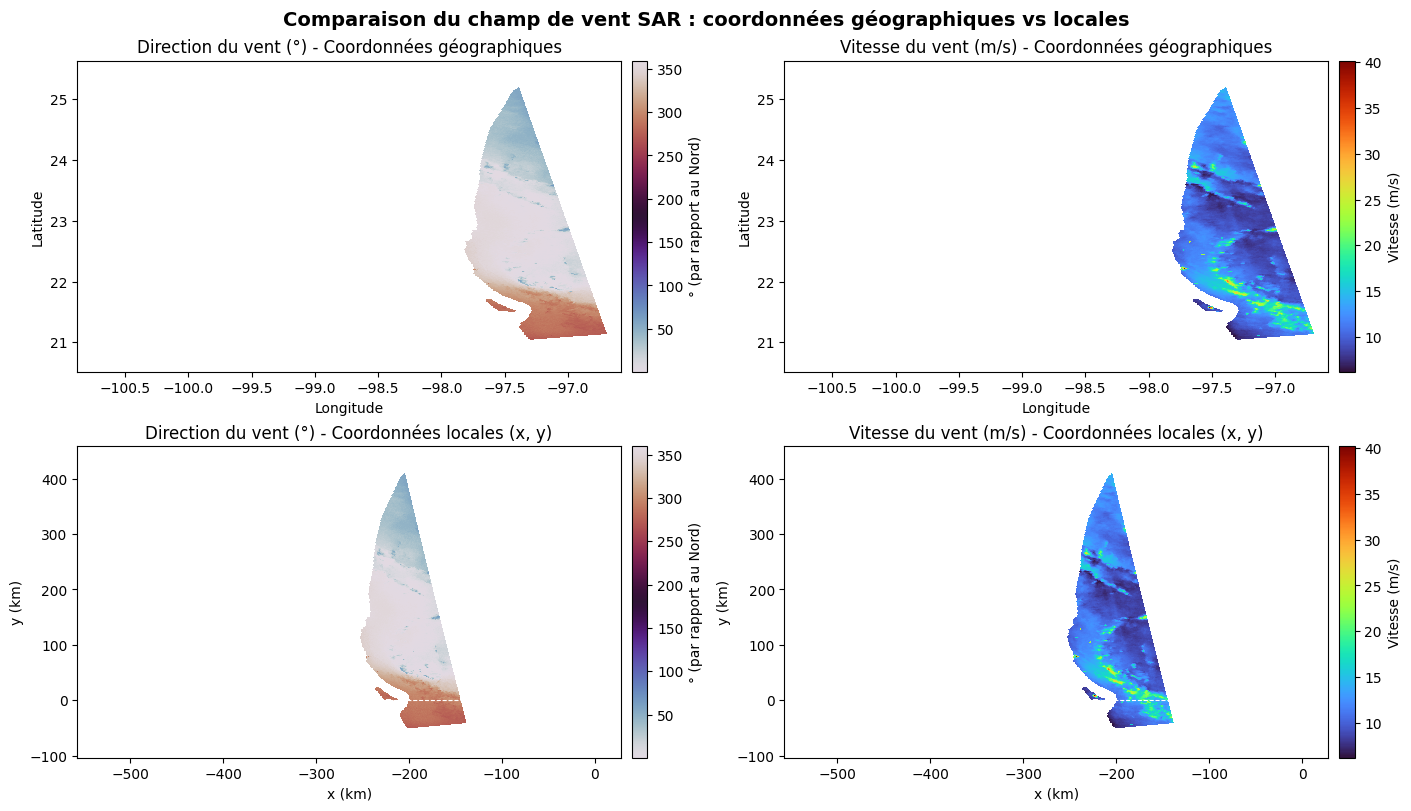

In [36]:

# Création de la figure
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# --- 1️⃣ Coordonnées géographiques ---
im00 = axes[0,0].pcolormesh(
    ds_sar_xy["owiLon"], ds_sar_xy["owiLat"],
    ds_sar_xy["owiWindDirection"], cmap="twilight", shading='auto'
)
axes[0,0].set_title("Direction du vent (°) - Coordonnées géographiques", fontsize=12)
axes[0,0].set_xlabel("Longitude")
axes[0,0].set_ylabel("Latitude")
cbar00 = fig.colorbar(im00, ax=axes[0,0], orientation="vertical", pad=0.02)
cbar00.set_label("° (par rapport au Nord)", rotation=90)

# --- 2️⃣ Coordonnées géographiques ---
im01 = axes[0,1].pcolormesh(
    ds_sar_xy["owiLon"], ds_sar_xy["owiLat"],
    ds_sar_xy["owiWindSpeed"], cmap="turbo", shading='auto'
)
axes[0,1].set_title("Vitesse du vent (m/s) - Coordonnées géographiques", fontsize=12)
axes[0,1].set_xlabel("Longitude")
axes[0,1].set_ylabel("Latitude")
cbar01 = fig.colorbar(im01, ax=axes[0,1], orientation="vertical", pad=0.02)
cbar01.set_label("Vitesse (m/s)", rotation=90)

# --- 3️⃣ Coordonnées locales (centrées cyclone) ---
im10 = axes[1,0].pcolormesh(
    ds_sar_xy["x_sar"], ds_sar_xy["y_sar"],
    ds_sar_xy["owiWindDirection"], cmap="twilight", shading='auto'
)
axes[1,0].set_title("Direction du vent (°) - Coordonnées locales (x, y)", fontsize=12)
axes[1,0].set_xlabel("x (km)")
axes[1,0].set_ylabel("y (km)")
axes[1,0].axhline(0, color='white', linestyle='--', linewidth=0.8)
axes[1,0].axvline(0, color='white', linestyle='--', linewidth=0.8)
cbar10 = fig.colorbar(im10, ax=axes[1,0], orientation="vertical", pad=0.02)
cbar10.set_label("° (par rapport au Nord)", rotation=90)

# --- 4️⃣ Coordonnées locales ---
im11 = axes[1,1].pcolormesh(
    ds_sar_xy["x_sar"], ds_sar_xy["y_sar"],
    ds_sar_xy["owiWindSpeed"], cmap="turbo", shading='auto'
)
axes[1,1].set_title("Vitesse du vent (m/s) - Coordonnées locales (x, y)", fontsize=12)
axes[1,1].set_xlabel("x (km)")
axes[1,1].set_ylabel("y (km)")
axes[1,1].axhline(0, color='white', linestyle='--', linewidth=0.8)
axes[1,1].axvline(0, color='white', linestyle='--', linewidth=0.8)
cbar11 = fig.colorbar(im11, ax=axes[1,1], orientation="vertical", pad=0.02)
cbar11.set_label("Vitesse (m/s)", rotation=90)

# --- Ajustement global ---
fig.suptitle("Comparaison du champ de vent SAR : coordonnées géographiques vs locales", fontsize=14, fontweight='bold')
plt.show()